## Markov Chains
This notebook explains Maximum Likelihood Estimation (MLE) before diving into Markov Chains using daily values for Nvidia (NVDA).

### Set Up

In [1]:
# Data and analysis libraries
import pandas as pd                   
import numpy as np                     
import random

# Visualisation
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [4]:
ticker = 'NVDA'
ts = pd.read_csv(f"data/{ticker}_1d_ohlcv.csv")
ts['date'] = pd.to_datetime(ts['date'], format='%Y-%m-%d')
ts = ts.sort_values('date')
ts.head()

,date,open,high,low,close,volume
0,2006-01-03,0.280934,0.294151,0.280017,0.292012,472812000
1,2006-01-04,0.294228,0.300646,0.291171,0.300187,510072000
2,2006-01-05,0.300263,0.307522,0.299729,0.306986,646092000
3,2006-01-06,0.310502,0.313175,0.298354,0.312029,623388000
4,2006-01-09,0.311877,0.322420,0.311189,0.320739,560484000


### Maximum Likelihood Estimate
Answering the question: "What parameter value would most plausibly generate the data I've observed"?

#### Bernoulli Distribution
Suppose a binary coin problem where we want to figure out the coin's bias.

$$
x_1, x_2, ..., x_n \sim \text{Bernoulli}(p)
$$

Likelihood:

$$
L(p) =
\prod_{i=1}^{n} p^{x_i}(1-p)^{1-x_i}
$$

Log-Likelihood:

$$
\ell(p) =
\sum_{i=1}^{n} x_i \log p
+
\sum_{i=1}^{n} (1-x_i)\log(1-p)
$$

Maximisation:

$$
\frac{d\ell}{dp} =
\frac{\sum x_i}{p}
-
\frac{n-\sum x_i}{1-p}
=0
$$

Solution:

$$
\hat p =
\frac{1}{n}
\sum_{i=1}^{n} x_i
$$

MLE estimate of p: 0.7


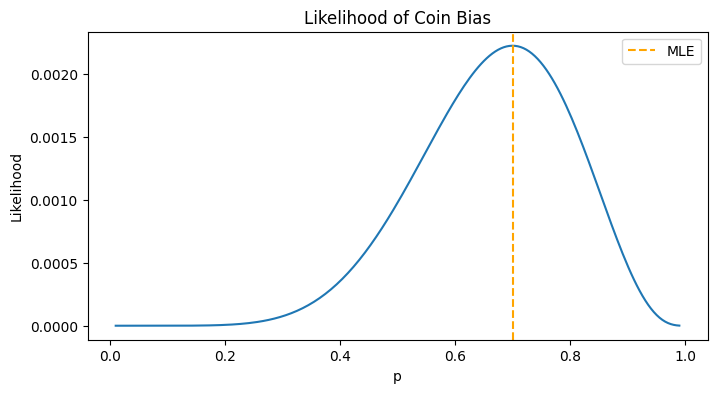

In [ ]:
# Observed flips
x = np.array([1,0,1,1,0,1,1,1,0,1]) # Heads = 1, Tails = 0

# MLE estimate
p_hat = x.mean()
print("MLE estimate of p:", p_hat)

def likelihood(p, x):
    return np.prod(p**x * (1-p)**(1-x))

grid = np.linspace(0.01,0.99,200)
L = [likelihood(p,x) for p in grid]

plt.figure(figsize=(8,4))
plt.plot(grid,L)

plt.axvline(x.mean(),linestyle='--',label='MLE', color='orange')

plt.xlabel("p")
plt.ylabel("Likelihood")
plt.title("Likelihood of Coin Bias")

plt.legend()
plt.show()

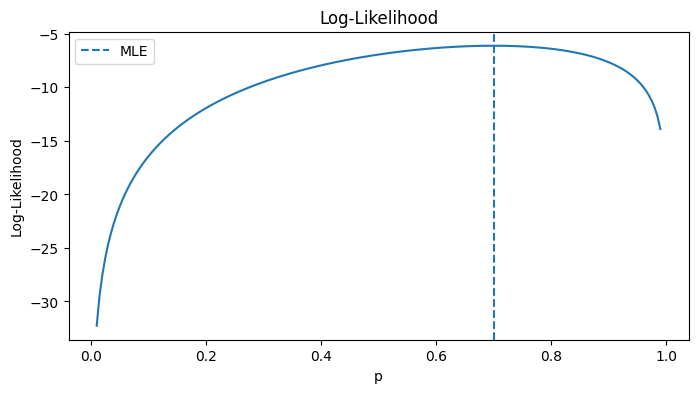

In [10]:
# Use log-likelihood to avoid "tiny numbers" issue, easier compute
def log_likelihood(p,x):
    return np.sum(x*np.log(p) + (1-x)*np.log(1-p))

LL = [log_likelihood(p,x) for p in grid]

plt.figure(figsize=(8,4))
plt.plot(grid,LL)

plt.axvline(x.mean(),linestyle='--',label='MLE')

plt.xlabel("p")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood")

plt.legend()
plt.show()

### Normal Distribution
Suppose we want to find the mean for a gaussian process.

Assume observations:

$$
x_1, x_2, ..., x_n \sim \mathcal{N}(\mu,\sigma^2)
$$

Assume the variance $\sigma^2$ is known.

Likelihood:

$$
L(\mu)
=
\prod_{i=1}^{n}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x_i-\mu)^2}{2\sigma^2}
\right)
$$

Log-likelihood:

$$
\ell(\mu)
=
-\frac{n}{2}\log(2\pi\sigma^2)
-
\frac{1}{2\sigma^2}
\sum_{i=1}^{n}
(x_i-\mu)^2
$$

Maximisation:

$$
\frac{d\ell}{d\mu}
=
\frac{1}{\sigma^2}
\sum_{i=1}^{n}
(x_i-\mu)
$$

Set equal to zero:

$$
\sum_{i=1}^{n}
(x_i-\mu)=0
$$

Solve:

$$
\hat{\mu}
=
\frac{1}{n}
\sum_{i=1}^{n} x_i
$$

Solution:

$$
\hat{\mu} = \bar{x}
$$

In [15]:
np.random.seed(0)

# True parameters
mu_true = 5
sigma = 2

n = 100

x = np.random.normal(mu_true, sigma, n)

# MLE estimate
mu_hat = x.mean()

print("True mu:", mu_true)
print("MLE mu_hat:", mu_hat)

True mu: 5
MLE mu_hat: 5.11961603106897


In [ ]:
def loglike_normal(mu, x, sigma):

    n = len(x)

    return (
        -n*np.log(sigma*np.sqrt(2*np.pi))
        - np.sum((x-mu)**2)/(2*sigma**2)
    )

grid = np.linspace(mu_hat-3, mu_hat+3, 400)

vals = [
    loglike_normal(m, x, sigma)
    for m in grid
]

mu_max = grid[np.argmax(vals)]

print("Sample mean:", mu_hat)
print("Numerical MLE:", mu_max)

Sample mean: 5.11961603106897
Numerical MLE: 5.112097234076488


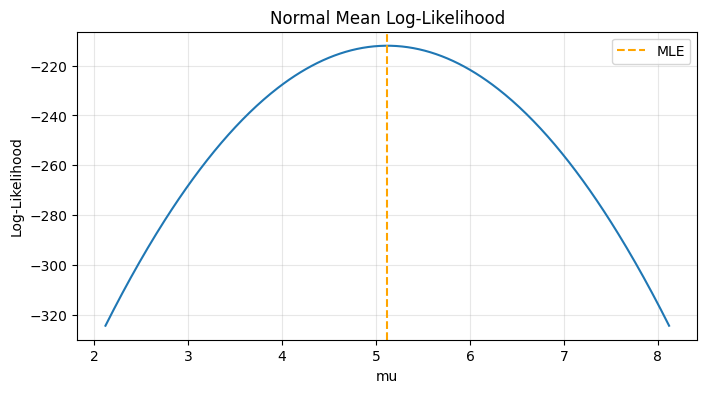

In [18]:

plt.figure(figsize=(8,4))

plt.plot(grid, vals)

plt.axvline(mu_hat, linestyle="--", label="MLE", color="orange")

plt.xlabel("mu")
plt.ylabel("Log-Likelihood")

plt.title("Normal Mean Log-Likelihood")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

If you experiment with the proofs, maximising the log-likelihood is equivalent to maximising:

$$
-\sum_{i=1}^{n}(x_i-\mu)^2
$$

which is equivalent to minimizing:

$$
\sum_{i=1}^{n}(x_i-\mu)^2
$$

Therefore:

$$
\hat{\mu}
=
\arg\max_\mu \ell(\mu)
=
\arg\min_\mu \sum (x_i-\mu)^2
$$

MLE for the Normal mean equals least squares. The $\mu$ that makes the data most probable is the $\mu$ that keeps the squared distances smallest.